# 문화누리카드 중분류 수요·선호 예측

**목적:** 국민여가활동조사(2021~2025)의 `가장 만족스러운 활동 1~3순위`를 순위가중해 성별·연령별 중분류 선호확률을 추정하고, 이를 100m 격자·행정동의 문화누리 대상자 수에 적용합니다.

| 항목 | 내용 |
|---|---|
| 목표변수 | 가장 만족스러운 활동 1~3순위의 순위가중 모델 중분류 |
| 최종 입력변수 | 성별×연령 결합코드, 조사연도 |
| 출력 | 성별×연령별 정책 8개 분야 확률 + 기타 선택지 확률 |
| 포함 분야 | 도서·영상·공연·미술·문화체험·관광지·스포츠관람·체육시설 |
| 기타 통합 | 음악(라디오·팟캐스트·스트리밍 청취)·교통수단(자동차 드라이브)·여행사(해외여행)·분류범위 밖 활동 |
| 체육용품 | 직접 선호라벨이 없어 선호확률 미산출(0으로 대체하지 않음) |
| 해석 | 과거 경험에 기반한 **만족활동 선호확률** |

### 왜 다항 로지스틱인가?

- 순위별 활동을 가중된 다중범주 관측값으로 바꾸며, 9개 클래스(정책 8개+기타) 확률합이 항상 100%입니다.
- 조사 가중치를 반영할 수 있고 계수·확률을 설명하기 쉽습니다.
- 지역 데이터에도 존재하는 성별·연령만 사용하며, 가산형과 결합형을 모두 검증한 뒤 공간 적용 목적에 맞는 결합형을 사용합니다.
- 음악은 라디오·팟캐스트·스트리밍 청취가 지역 가맹점 접근성 수요를 직접 대표하지 않아 정책 출력에서 제외하고 기타에 포함합니다. 체육용품도 `사이클링·산악자전거`만으로 구매 선호를 대표하기 어려워 동일하게 기타에 포함합니다. 원본 활동명과 가맹점 공급·접근성 분류는 그대로 보존합니다.

### 분석 흐름

`활동코드 매핑 → 동일 중분류 점수 합산 → 3:2:1 순위가중 → 다항 로지스틱 학습 → 연도검증 → 격자·행정동 수요 계산`

| 단계 | 사용 연도 | 역할 |
|---|---|---|
| 응답자 5-Fold | 2021~2024를 5묶음으로 나누고, 매번 4묶음 학습·1묶음 검증 | 동일 시기 내 안정성 확인 |
| 연도검증 1 | 학습 2021 → 검증 2022 | 시간 일반화 확인 |
| 연도검증 2 | 학습 2021~2022 → 검증 2023 | 시간 일반화 확인 |
| 연도검증 3 | 학습 2021~2023 → 검증 2024 | 시간 일반화 확인 |
| 모델 선택 | 5-Fold·연도검증 평균 Log Loss를 50:50 결합 | 변수구조·C 결정 |
| 최종평가 | 학습 2021~2024 → 테스트 2025 | 선택 완료 후 성능 확인 |
| 공간용 확률 | 학습 2021~2024, 연도조건 2024 | 격자·행정동 수요 입력 |

$$
D_{g,c}=Σ_{s,a}N_{g,s,a}p_{s,a,c}
$$

- $D_{g,c}$: 격자 $g$의 분야 $c$ 잠재수요
- $N_{g,s,a}$: 격자 $g$의 성별 $s$·연령 $a$ 대상자 수
- $p_{s,a,c}$: 해당 집단의 분야 $c$ 선호확률
- $g,s,a,c$: 각각 격자·성별·연령·중분류

> 같은 응답자의 동일 중분류는 1~3순위 점수를 합산하고, 전체 3:2:1 점수를 응답자 내부에서 합계 1로 정규화합니다. 향후 희망활동은 사용하지 않았으며, 결과는 **만족활동 기반 추정치**입니다.

VS Code에서 프로젝트 `.venv` 커널을 선택한 뒤 **Run All**을 실행합니다.


In [1]:
from pathlib import Path
import json
import os
import subprocess
import sys

import matplotlib.pyplot as plt
from matplotlib import font_manager
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

def find_project_root():
    configured = os.environ.get('ORACLE_PROJECT_ROOT')
    starts = ([Path(configured).expanduser()] if configured else []) + [Path.cwd()]
    for start in starts:
        for candidate in (start, *start.parents):
            if (candidate / '.git').exists() and (candidate / 'data').is_dir():
                return candidate.resolve()
    raise FileNotFoundError('Oracle-Project 저장소를 찾지 못했습니다.')

ROOT = find_project_root()
MODEL_DIR = ROOT / 'data/processed/preference_analysis/model'
os.chdir(ROOT)
sys.path.insert(0, str(ROOT / 'src'))

pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 140)
sns.set_theme(style='whitegrid')

def configure_korean_font():
    font_candidates = [
        Path('/System/Library/Fonts/AppleSDGothicNeo.ttc'),
        Path('/System/Library/Fonts/Supplemental/AppleGothic.ttf'),
        Path('C:/Windows/Fonts/malgun.ttf'),
        Path('/usr/share/fonts/truetype/nanum/NanumGothic.ttf'),
        Path('/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc'),
    ]
    font_path = next((path for path in font_candidates if path.exists()), None)
    if font_path is None:
        raise RuntimeError('한글 그래프용 폰트를 찾지 못했습니다. Apple SD Gothic Neo, 맑은 고딕, 나눔고딕 중 하나를 설치하세요.')
    font_manager.fontManager.addfont(font_path)
    font_name = font_manager.FontProperties(fname=font_path).get_name()
    plt.rcParams.update({
        'font.family': font_name,
        'axes.unicode_minus': False,
        'figure.dpi': 120,
    })
    return font_name

KOREAN_FONT = configure_korean_font()

print(f'Project: {ROOT}')
print(f'Python : {sys.executable}')
print(f'한글 폰트: {KOREAN_FONT}')


Project: .
Python : ./.venv/bin/python
한글 폰트: Apple SD Gothic Neo


## 1. 중분류 매핑 및 모델 학습

1. 만족활동 1~3순위를 정책 8개 분야와 `기타·문화누리 비대응`으로 매핑합니다. 음악 활동은 원본 라벨을 보존한 채 기타로 통합합니다.
2. 동일 중분류는 순위점수를 합산하고 전체 3:2:1 점수를 응답자 내부에서 정규화합니다.
3. 조사 가중 다항 로지스틱으로 9개 클래스(정책 8개+기타) 확률을 동시에 학습합니다. 기존 결과가 있으면 재사용하며, 다시 학습하려면 다음 셀의 `REBUILD_MODEL=True`로 바꿉니다.

$$
P(Y_i=c | x_i)=e^{η_{ic}}\,/\,(Σ_{k=1}^{K}e^{η_{ik}})
$$

- **선호확률 식:** 성별·연령·연도로 계산한 분야별 점수 $η_{ic}$를 Softmax로 변환합니다. 따라서 한 응답자의 9개 클래스 확률 합은 100%입니다.
  - $x_i$: 응답자 $i$의 성별·연령·조사연도
  - $c$: 예측하려는 중분류
  - $η_{ic}$: 모델이 응답자 $i$와 분야 $c$에 대해 계산한 점수
  - $K$: 전체 모델 클래스 개수(현재 정책 8개+기타=9개)

$$
w_{ic}=w_i\frac{\sum_{r=1}^{3}q_rI(y_{ir}=c)}{\sum_{r=1}^{3}q_r},\qquad(q_1,q_2,q_3)=(3,2,1)
$$

- **학습가중치 식:** 설문가중치 $w_i$에 만족활동 1·2·3순위 점수 3:2:1을 반영합니다. 예를 들어 `공연-체육-공연`이면 공연은 $(3+1)/6$, 체육은 $2/6$의 비중으로 학습됩니다.
  - $w_{ic}$: 응답자 $i$가 중분류 $c$의 학습에 기여하는 최종 가중치
  - $w_i$: 설문 원자료의 응답자 최종가중치
  - $r$, $q_r$: 순위와 해당 순위 점수(1순위 3, 2순위 2, 3순위 1)
  - $y_{ir}$: 응답자 $i$가 순위 $r$에서 선택한 중분류
  - $I(y_{ir}=c)$: 선택한 중분류가 $c$이면 1, 아니면 0인 지시함수

응답자별 유효가중치 합은 원래 `최종가중치`와 동일합니다. 다음 셀에서는 목표변수·순위가중치·확률합을 자동 검증합니다.


In [2]:
def run_module(module_name):
    env = os.environ.copy()
    env['PYTHONPATH'] = str(ROOT / 'src')
    completed = subprocess.run(
        [sys.executable, '-m', module_name],
        cwd=ROOT,
        env=env,
        capture_output=True,
        text=True,
    )
    if completed.returncode != 0:
        message = '\n'.join(completed.stderr.splitlines()[-20:])
        raise RuntimeError(f'{module_name} 실행 실패:\n{message}')

REBUILD_MODEL = False
required_model_files = [
    MODEL_DIR / 'multinomial_logistic_2021_2024.joblib',
    MODEL_DIR / 'model_score_2024_2025.csv',
    MODEL_DIR / 'sex_age_middle_category_preference_2024.csv',
]
if REBUILD_MODEL or not all(path.exists() for path in required_model_files):
    run_module('preference_analysis.build_mapping')
    run_module('preference_analysis.train_model')
    print('✓ 매핑과 다항 로지스틱 모델을 다시 계산했습니다.')
else:
    print('✓ 기존 모델 결과를 사용합니다. REBUILD_MODEL=True이면 다시 계산합니다.')


✓ 기존 모델 결과를 사용합니다. REBUILD_MODEL=True이면 다시 계산합니다.


In [3]:
scores = pd.read_csv(MODEL_DIR / 'model_score_temporal_2022_2025.csv', encoding='utf-8-sig')
tuning = pd.read_csv(
    MODEL_DIR / 'multinomial_tuning_temporal_cv_2022_2024.csv',
    encoding='utf-8-sig',
)
temporal_folds = pd.read_csv(
    MODEL_DIR / 'multinomial_tuning_temporal_cv_by_fold_2022_2024.csv',
    encoding='utf-8-sig',
)
grouped_tuning = pd.read_csv(
    MODEL_DIR / 'multinomial_tuning_grouped_cv_2021_2024.csv',
    encoding='utf-8-sig',
)
grouped_folds = pd.read_csv(
    MODEL_DIR / 'multinomial_tuning_grouped_cv_by_fold_2021_2024.csv',
    encoding='utf-8-sig',
)
combined_tuning = pd.read_csv(
    MODEL_DIR / 'multinomial_tuning_combined_cv.csv',
    encoding='utf-8-sig',
)
validation_2025 = pd.read_csv(
    MODEL_DIR / 'model_validation_2025_by_category.csv', encoding='utf-8-sig'
)
sex_age_probability = pd.read_csv(
    MODEL_DIR / 'sex_age_middle_category_preference_2024.csv',
    encoding='utf-8-sig',
)
metadata = json.loads(
    (MODEL_DIR / 'multinomial_model_metadata.json').read_text(encoding='utf-8')
)

assert metadata['future_preference_columns_used'] is False
assert metadata['rank_scores'] == {'1': 3.0, '2': 2.0, '3': 1.0}
assert metadata['grouped_cv_split_unit'] == 'respondent_id'
assert metadata['final_test_year'] == 2025
assert metadata['selected_feature_mode'] == 'sex_age_interaction'
assert metadata['unmodeled_preference_categories'] == ['체육용품']
assert '체육용품' not in set(sex_age_probability['middle_category'])
assert np.allclose(
    sex_age_probability.groupby(['sex_code', 'age_code'])['preference_probability'].sum(),
    1.0,
)
print(f"✓ Target: {metadata['target']}")
print(f"✓ Selected feature mode: {metadata['selected_feature_mode']}")
print(f"✓ Selected C: {metadata['selected_c']}")
print(f"✓ Validation years: {metadata['tuning_validation_years']}")
print(f"✓ Grouped CV: {metadata['grouped_cv_folds']}-Fold on {metadata['grouped_cv_years']} by respondent")
print(f"✓ Validation selection agreement: {metadata['temporal_grouped_selection_agreement']}")
print(f"✓ Final selection rule: {metadata['feature_mode_selection_rule']}")
print(f"✓ Rank scores: {metadata['rank_scores']} (normalized within respondent)")
print(f"✓ Duplicate rule: {metadata['duplicate_middle_category_handling']}")
print('✓ Sports goods preference: not estimated (not replaced with zero)')
print(f"✓ Final train: {metadata['respondent_counts']['train_2021_2024']:,} respondents / {metadata['model_row_counts']['train_2021_2024']:,} weighted rank rows")
print('✓ Future desired activities used: No')
print('✓ Sex-age probability sums: 100% for every cell')


✓ Target: 가장 만족스러운 여가활동 1~3순위의 순위가중 모델 중분류
✓ Selected feature mode: sex_age_interaction
✓ Selected C: 0.1
✓ Validation years: [2022, 2023, 2024]
✓ Grouped CV: 5-Fold on [2021, 2022, 2023, 2024] by respondent
✓ Validation selection agreement: False
✓ Final selection rule: 결합 Log Loss 최저값과 0.001 이내 후보 중 성별×연령 결합형을 우선하고, 같은 구조에서는 더 작은 C를 선택
✓ Rank scores: {'1': 3.0, '2': 2.0, '3': 1.0} (normalized within respondent)
✓ Duplicate rule: 응답자별 동일 중분류의 3:2:1 순위점수를 누적
✓ Sports goods preference: not estimated (not replaced with zero)
✓ Final train: 40,210 respondents / 84,710 weighted rank rows
✓ Future desired activities used: No
✓ Sex-age probability sums: 100% for every cell


## 2. 응답자 5-Fold·연도 순차검증 및 2025 최종 성능

**5-Fold란?** 데이터를 5개 묶음으로 나눈 뒤, 4개로 학습하고 남은 1개로 검증하는 과정을 검증 묶음을 바꿔가며 5번 반복하는 교차검증입니다. 5개 결과의 평균으로 특정 분할에 우연히 잘 맞은 모델인지 확인합니다.

2021~2024년은 응답자 단위 5-Fold로 나눠 매번 약 80% 학습·20% 검증하고, 같은 응답자의 중분류 행은 항상 한 fold에 둡니다. 동시에 `2021→2022`, `2021~2022→2023`, `2021~2023→2024` 연도검증을 수행합니다. 두 평균 Log Loss를 50:50으로 결합해 모델을 선택한 뒤, 2021~2024년으로 재학습하고 2025년을 최종 평가합니다.

- **장점:** 무작위 분할의 안정성과 미래 연도 변화 대응력을 함께 확인하며, 응답자 누출을 방지합니다.
- **단점:** 학습 횟수와 실행시간이 늘고, 두 검증을 50:50으로 결합하는 것은 분석자가 정한 기준입니다. 2025년은 모델 선택에 사용하지 않습니다.

$$
LogLoss=-\,Σ_iΣ_cw_{ic}\log(p_{i,c})\,/\,Σ_iΣ_cw_{ic}
$$

$$
LogLossScore=100e^{-LogLoss}
$$

$$
DistributionMatch=100\left(1-0.5Σ_c|\hat p_c-p_c|\right)
$$

- $i,c$: 각각 응답자와 중분류, $w_{ic}$: 순위·설문가중치를 반영한 유효가중치, $p_{i,c}$: 모델의 개인별 예측확률
- $LogLossScore$: Log Loss를 보기 쉽게 0~100 방향으로 변환한 프로젝트 보조점수이며, 공식 정확도 지표는 아닙니다.
- $p_c$, $\hat p_c$: 각각 중분류 $c$의 실제 가중 비율과 평균 예측 비율입니다.
- Log Loss는 낮을수록, Log Loss Score는 높을수록 좋습니다.
- Accuracy·Macro F1·Top-3·Brier는 보조 성능지표입니다.
- Distribution Match는 전체 비율만 평가해 모든 사람에게 같은 평균확률을 줘도 높을 수 있습니다. 따라서 **개인별 확률 전체를 평가하고 과도하게 확신한 오답을 벌점 주는 Log Loss를 모델 선택 기준**으로 사용합니다.


In [4]:
score_view = scores[[
    'evaluation_year', 'training_years', 'model', 'feature_mode',
    'accuracy', 'macro_f1', 'top3_accuracy', 'log_loss', 'log_loss_score',
    'log_loss_skill_score_vs_baseline', 'multiclass_brier',
    'distribution_match_score',
]].copy()
score_view['model'] = score_view['model'].map({
    'multinomial_logistic': '다항 로지스틱',
    'weighted_prior_baseline': '가중 사전확률 기준선',
})
score_view['feature_mode'] = score_view['feature_mode'].map({
    'sex_age_interaction': '성별×연령 결합형',
    'additive': '성별·연령 가산형',
    'weighted_prior': '가중 사전확률',
})
score_view_ko = score_view.rename(columns={
    'evaluation_year': '평가연도',
    'training_years': '학습연도',
    'model': '모델',
    'feature_mode': '변수구조',
    'accuracy': '정확도',
    'macro_f1': '매크로 F1',
    'top3_accuracy': '상위3 정확도',
    'log_loss': '로그손실',
    'log_loss_score': '로그손실 점수',
    'log_loss_skill_score_vs_baseline': '기준선 대비 개선점수',
    'multiclass_brier': '다중 Brier',
    'distribution_match_score': '분포 일치점수',
})
display(
    score_view_ko.style
    .format({
        '정확도': '{:.2%}',
        '매크로 F1': '{:.2%}',
        '상위3 정확도': '{:.2%}',
        '로그손실': '{:.4f}',
        '로그손실 점수': '{:.2f}',
        '기준선 대비 개선점수': '{:+.2f}',
        '다중 Brier': '{:.3f}',
        '분포 일치점수': '{:.2f}',
    })
    .hide(axis='index')
)

final_2025 = score_view.loc[score_view['evaluation_year'].eq(2025)]
model_score = final_2025.loc[final_2025['model'].eq('다항 로지스틱')].iloc[0]
baseline_score = final_2025.loc[final_2025['model'].eq('가중 사전확률 기준선')].iloc[0]
print(
    f"상위3 정확도 개선: {(model_score['top3_accuracy'] - baseline_score['top3_accuracy']) * 100:+.2f}%p | "
    f"로그손실 점수: {model_score['log_loss_score']:.2f}/100 | "
    f"기준선 대비 개선점수: {model_score['log_loss_skill_score_vs_baseline']:+.2f}"
)


평가연도,학습연도,모델,변수구조,정확도,매크로 F1,상위3 정확도,로그손실,로그손실 점수,기준선 대비 개선점수,다중 Brier,분포 일치점수
2022,2021,다항 로지스틱,성별×연령 결합형,47.22%,7.13%,82.77%,1.4794,22.78,+1.68,0.702,92.60
2022,2021,가중 사전확률 기준선,가중 사전확률,47.22%,7.13%,81.63%,1.5047,22.21,+0.00,0.708,92.71
2023,2021-2022,다항 로지스틱,성별×연령 결합형,44.44%,6.84%,80.17%,1.5416,21.40,+1.40,0.724,93.18
2023,2021-2022,가중 사전확률 기준선,가중 사전확률,44.44%,6.84%,79.29%,1.5634,20.94,+0.00,0.727,94.03
2024,2021-2022-2023,다항 로지스틱,성별×연령 결합형,42.66%,6.64%,80.19%,1.5368,21.51,+2.33,0.726,96.40
2024,2021-2022-2023,가중 사전확률 기준선,가중 사전확률,42.66%,6.64%,78.73%,1.5735,20.73,+0.00,0.737,92.52
2025,2021-2024,다항 로지스틱,성별×연령 결합형,41.94%,6.57%,78.60%,1.5695,20.81,+2.34,0.736,94.19
2025,2021-2024,가중 사전확률 기준선,가중 사전확률,41.94%,6.57%,77.67%,1.6072,20.04,+0.00,0.743,93.98


상위3 정확도 개선: +0.93%p | 로그손실 점수: 20.81/100 | 기준선 대비 개선점수: +2.34


## 3. 변수 구조와 C 선택

$$
η^{add}_{ic}=β_{0c}+β_{sex,c}+β_{age,c}+β_{year,c}
$$

$$
η^{int}_{ic}=β_{0c}+β_{sex×age,c}+β_{year,c}
$$

- $η^{add}_{ic}$, $η^{int}_{ic}$: 각각 가산형과 성별×연령 결합형이 계산한 응답자 $i$의 분야 $c$ 점수
- $β_{0c}$: 분야 $c$의 기준점수, 각 $β$: 성별·연령·연도 또는 성별×연령 조합의 분야별 효과
- 가산형은 성별·연령 효과를 더하고, 결합형은 각 성별×연령 조합에 별도 효과를 부여합니다.
가산형과 성별×연령 결합형을 `연도 순차검증 평균 Log Loss 50% + 응답자 5-Fold 평균 Log Loss 50%`로 비교합니다. $C=1/λ$이므로 C가 작을수록 L2 규제가 강합니다. 결합형의 성능 우위가 크다고 가정하지 않으며, 최저 결합 Log Loss와 0.001 이내일 때만 공간 산출 목적에 맞는 성별×연령 결합형을 우선합니다. 같은 구조에서는 더 작은 C를 선택하고, 2025년은 이 선택에 사용하지 않습니다.


In [5]:
architecture_view = (
    combined_tuning.sort_values(['feature_mode', 'combined_mean_log_loss', 'c_value'])
    .groupby('feature_mode', as_index=False)
    .head(1)
    [[
        'feature_mode', 'c_value', 'temporal_mean_log_loss',
        'grouped_mean_log_loss', 'combined_mean_log_loss',
        'combined_log_loss_score', 'combined_mean_top3_accuracy',
    ]]
)
architecture_view['feature_mode'] = architecture_view['feature_mode'].map({
    'sex_age_interaction': '성별×연령 결합형',
    'additive': '성별·연령 가산형',
})
architecture_view = architecture_view.rename(columns={
    'feature_mode': '변수구조',
    'c_value': 'C값',
    'temporal_mean_log_loss': '연도검증 평균 로그손실',
    'grouped_mean_log_loss': '5-Fold 평균 로그손실',
    'combined_mean_log_loss': '결합 평균 로그손실',
    'combined_log_loss_score': '결합 로그손실 점수',
    'combined_mean_top3_accuracy': '결합 상위3 정확도',
})
print('변수구조별 최적 결합 후보')
display(
    architecture_view.style
    .format({
        'C값': '{:g}',
        '연도검증 평균 로그손실': '{:.4f}',
        '5-Fold 평균 로그손실': '{:.4f}',
        '결합 평균 로그손실': '{:.4f}',
        '결합 로그손실 점수': '{:.2f}',
        '결합 상위3 정확도': '{:.2%}',
    })
    .hide(axis='index')
)

tuning_view = combined_tuning.loc[
    combined_tuning['feature_mode'].eq(metadata['selected_feature_mode']),
    [
        'c_value', 'temporal_mean_log_loss', 'grouped_mean_log_loss',
        'combined_mean_log_loss', 'combined_log_loss_score',
        'combined_mean_top3_accuracy', 'within_log_loss_tolerance', 'selected',
    ],
].sort_values('c_value')
tuning_view = tuning_view.rename(columns={
    'c_value': 'C값',
    'temporal_mean_log_loss': '연도검증 평균 로그손실',
    'grouped_mean_log_loss': '5-Fold 평균 로그손실',
    'combined_mean_log_loss': '결합 평균 로그손실',
    'combined_log_loss_score': '결합 로그손실 점수',
    'combined_mean_top3_accuracy': '결합 상위3 정확도',
    'within_log_loss_tolerance': '로그손실 허용범위',
    'selected': '최종선택',
})
print('성별×연령 결합형의 C 후보 비교')
display(
    tuning_view.style
    .format({
        'C값': '{:g}',
        '연도검증 평균 로그손실': '{:.4f}',
        '5-Fold 평균 로그손실': '{:.4f}',
        '결합 평균 로그손실': '{:.4f}',
        '결합 로그손실 점수': '{:.2f}',
        '결합 상위3 정확도': '{:.2%}',
    })
    .hide(axis='index')
)


변수구조별 최적 결합 후보


변수구조,C값,연도검증 평균 로그손실,5-Fold 평균 로그손실,결합 평균 로그손실,결합 로그손실 점수,결합 상위3 정확도
성별·연령 가산형,0.3,1.5182,1.4654,1.4918,22.50,81.64%
성별×연령 결합형,3,1.5184,1.4642,1.4913,22.51,81.71%


성별×연령 결합형의 C 후보 비교


C값,연도검증 평균 로그손실,5-Fold 평균 로그손실,결합 평균 로그손실,결합 로그손실 점수,결합 상위3 정확도,로그손실 허용범위,최종선택
0.0001,1.5395,1.4933,1.5164,21.95,80.38%,False,False
0.0003,1.5368,1.4885,1.5126,22.03,80.44%,False,False
0.001,1.5321,1.4815,1.5068,22.16,81.10%,False,False
0.003,1.5272,1.4752,1.5012,22.29,81.51%,False,False
0.01,1.5233,1.4699,1.4966,22.39,81.38%,False,False
0.03,1.5209,1.4669,1.4939,22.45,81.67%,False,False
0.1,1.5192,1.4653,1.4922,22.49,81.73%,True,True
0.3,1.5186,1.4646,1.4916,22.50,81.72%,True,False
1,1.5184,1.4643,1.4913,22.51,81.71%,True,False
3,1.5184,1.4642,1.4913,22.51,81.71%,True,False


## 4. 2025 실제 비율과 예측 비율

$$
r^{obs}_c=Σ_iw_{ic}\,/\,Σ_iΣ_kw_{ik},\qquad r^{pred}_c=Σ_iw_ip_{i,c}\,/\,Σ_iw_i
$$

- $r^{obs}_c$: 2025년에 실제로 중분류 $c$가 선택된 가중 비율
- $r^{pred}_c$: 2025년 응답자에게 예측한 중분류 $c$ 확률의 가중 평균
- $w_{ic}$: 실제 순위 선택의 유효가중치, $w_i$: 응답자 설문가중치, $p_{i,c}$: 개인별 예측확률
막대가 가까울수록 분야별 전체 배분이 잘 맞은 것입니다. 집계 결과이므로 개인별 확률 품질은 Log Loss와 함께 봅니다.


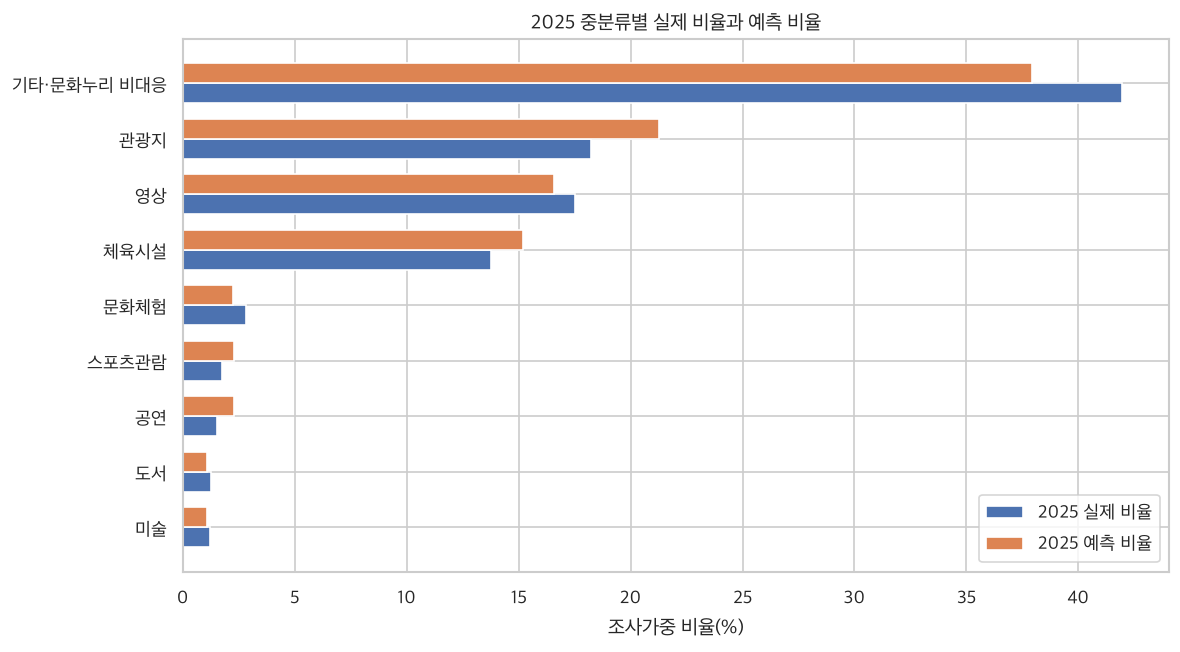

중분류,실제 비율,예측 비율,예측-실제 차이,절대차이(%p)
기타·문화누리 비대응,41.94%,37.93%,-4.02%,4.02%p
관광지,18.22%,21.27%,+3.05%,3.05%p
체육시설,13.78%,15.21%,+1.43%,1.43%p
영상,17.51%,16.60%,-0.91%,0.91%p
공연,1.51%,2.30%,+0.79%,0.79%p


In [6]:
plot_data = validation_2025.copy()
plot_data = plot_data.sort_values('observed_rate')

y = np.arange(len(plot_data))
fig, ax = plt.subplots(figsize=(10, 5.6))
ax.barh(y - 0.18, plot_data['observed_rate'] * 100, height=0.36, label='2025 실제 비율')
ax.barh(y + 0.18, plot_data['predicted_rate'] * 100, height=0.36, label='2025 예측 비율')
ax.set_yticks(y, plot_data['middle_category'])
ax.set_xlabel('조사가중 비율(%)')
ax.set_title('2025 중분류별 실제 비율과 예측 비율')
ax.legend()
plt.tight_layout()
plt.show()

largest_errors = (
    validation_2025
    .nlargest(5, 'absolute_difference_pp')
    [['middle_category', 'observed_rate', 'predicted_rate', 'difference', 'absolute_difference_pp']]
    .rename(columns={
        'middle_category': '중분류',
        'observed_rate': '실제 비율',
        'predicted_rate': '예측 비율',
        'difference': '예측-실제 차이',
        'absolute_difference_pp': '절대차이(%p)',
    })
)
display(
    largest_errors.style
    .format({
        '실제 비율': '{:.2%}',
        '예측 비율': '{:.2%}',
        '예측-실제 차이': '{:+.2%}',
        '절대차이(%p)': '{:.2f}%p',
    })
    .hide(axis='index')
)


## 5. 2024 성별×연령별 선호확률

2024년 조건에서 성별×연령별 정책 8개 분야의 **절대확률**을 표시합니다. 기타 범주는 화면에서만 제외하므로 히트맵 한 행의 합은 100%보다 작을 수 있습니다. `preference_probability_absolute=p(c)`는 잠재수요 계산에 사용하고, `preference_share_conditional_mnc=p(c)/(1-p(other))`는 8개 분야 내부의 상대구성 표시에만 사용합니다.

$$
D_{g,c}=Σ_{s,a}N_{g,s,a}p_{s,a,c}
$$

- $D_{g,c}$: 격자 $g$의 분야 $c$ 잠재수요
- $N_{g,s,a}$: 격자 $g$의 성별 $s$·연령 $a$ 문화누리 대상자 수
- $p_{s,a,c}$: 해당 성별×연령 집단이 분야 $c$를 선호할 확률
이 확률을 격자별 대상자 수에 곱해 분야별 잠재수요를 계산합니다.


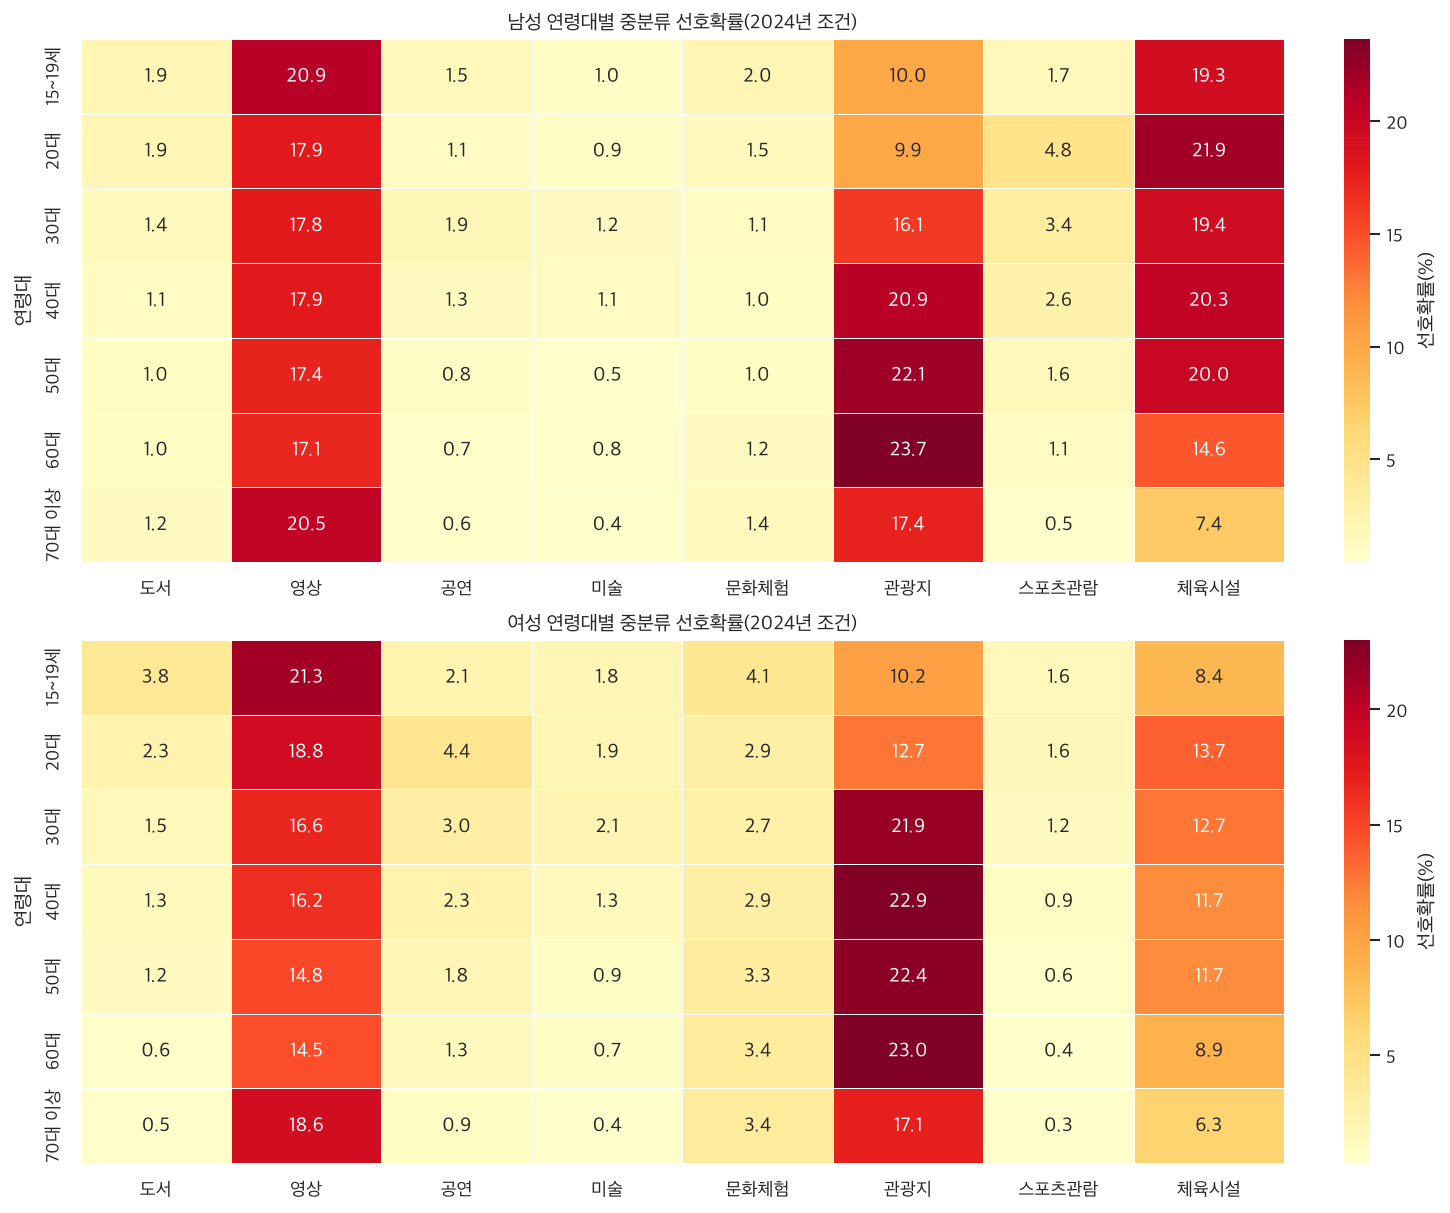

In [7]:
AGE_KO = {1: '15~19세', 2: '20대', 3: '30대', 4: '40대', 5: '50대', 6: '60대', 7: '70대 이상'}
POLICY_CATEGORIES = [
    '도서', '영상', '공연', '미술',
    '문화체험', '관광지', '스포츠관람', '체육시설',
]

policy_probability = sex_age_probability.loc[
    sex_age_probability['middle_category'].isin(POLICY_CATEGORIES)
].copy()
policy_probability['probability_pct'] = policy_probability['preference_probability_absolute'] * 100

fig, axes = plt.subplots(2, 1, figsize=(12, 10), constrained_layout=True)
for ax, sex_code, sex_name in zip(axes, [1, 2], ['남성', '여성'], strict=True):
    pivot = (
        policy_probability.loc[policy_probability['sex_code'].eq(sex_code)]
        .pivot(index='age_code', columns='middle_category', values='probability_pct')
        .reindex(index=range(1, 8), columns=POLICY_CATEGORIES)
        .rename(index=AGE_KO)
    )
    sns.heatmap(
        pivot, ax=ax, cmap='YlOrRd', annot=True, fmt='.1f',
        linewidths=0.4, cbar_kws={'label': '선호확률(%)'},
    )
    ax.set_title(f'{sex_name} 연령대별 중분류 선호확률(2024년 조건)')
    ax.set_xlabel('')
    ax.set_ylabel('연령대')
plt.show()


## 6. 결과 해석

- **모델 선택:** 2021~2024 응답자 5-Fold와 2022~2024 연도검증의 결합 Log Loss를 사용합니다.
- **최종 확인:** 2025년 Log Loss·Brier·Top-3와 분야별 오차를 확인합니다.
- **결합형 장점:** 연령에 따라 성별 효과가 달라지는 선호 차이를 14개 성별×연령 셀로 표현합니다.
- **결합형 한계:** 가산형보다 모수가 많아 희소 분야·작은 인구셀에서 변동성이 커질 수 있으므로 C 규제와 검증을 유지합니다.
- **체육용품 처리:** 국민여가활동조사로 선호확률을 산출하지 않으며 0으로 해석하지 않습니다. 공급·접근성 분석에서는 별도 가맹점 분야로 유지합니다.
- **공간 적용:** `sex_age_middle_category_preference_2024.csv`의 절대확률을 격자별 성별×연령 대상자 수와 결합합니다. 조건부 구성비는 절대 잠재수요 계산에 사용하지 않습니다.

> 만 15세 미만에는 적용하지 않습니다. 결과는 인과효과나 확정 인원이 아닌 1~3순위 순위가중 만족활동 기반 추정치이며, 작은 격자는 불확실성이 큽니다.


In [8]:
print('주요 산출 파일')
print('-', MODEL_DIR / 'model_score_temporal_2022_2025.csv')
print('-', MODEL_DIR / 'multinomial_tuning_temporal_cv_2022_2024.csv')
print('-', MODEL_DIR / 'model_validation_2025_by_category.csv')
print('-', MODEL_DIR / 'model_calibration_summary_2024_2025.csv')
print('-', MODEL_DIR / 'sex_age_middle_category_preference_2024.csv')
print('-', MODEL_DIR / 'multinomial_model_metadata.json')


주요 산출 파일
- ./data/processed/preference_analysis/model/model_score_temporal_2022_2025.csv
- ./data/processed/preference_analysis/model/multinomial_tuning_temporal_cv_2022_2024.csv
- ./data/processed/preference_analysis/model/model_validation_2025_by_category.csv
- ./data/processed/preference_analysis/model/model_calibration_summary_2024_2025.csv
- ./data/processed/preference_analysis/model/sex_age_middle_category_preference_2024.csv
- ./data/processed/preference_analysis/model/multinomial_model_metadata.json
